In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print("Libraries imported successfully!")


Libraries imported successfully!


In [3]:
url = "https://raw.githubusercontent.com/krishnaik06/playstore-Dataset/main/googleplaystore.csv"

df = pd.read_csv(url)

print("Dataset loaded successfully!")
print("Dataset shape:", df.shape)
print("\nFirst 5 rows:")
display(df.head())


Dataset loaded successfully!
Dataset shape: (10841, 13)

First 5 rows:


,App,Category,Rating,Reviews,Size,Installs,Type,Price,Content Rating,Genres,Last Updated,Current Ver,Android Ver
0,Photo Editor & Candy Camera & Grid & ScrapBook,ART_AND_DESIGN,4.1,159,19M,"10,000+",Free,0,Everyone,Art & Design,"January 7, 2018",1.0.0,4.0.3 and up
1,Coloring book moana,ART_AND_DESIGN,3.9,967,14M,"500,000+",Free,0,Everyone,Art & Design;Pretend Play,"January 15, 2018",2.0.0,4.0.3 and up
2,"U Launcher Lite – FREE Live Cool Themes, Hide ...",ART_AND_DESIGN,4.7,87510,8.7M,"5,000,000+",Free,0,Everyone,Art & Design,"August 1, 2018",1.2.4,4.0.3 and up
3,Sketch - Draw & Paint,ART_AND_DESIGN,4.5,215644,25M,"50,000,000+",Free,0,Teen,Art & Design,"June 8, 2018",Varies with device,4.2 and up
4,Pixel Draw - Number Art Coloring Book,ART_AND_DESIGN,4.3,967,2.8M,"100,000+",Free,0,Everyone,Art & Design;Creativity,"June 20, 2018",1.1,4.4 and up


In [4]:
# Check dataset information
print("Dataset shape:", df.shape)
print("\nColumn names:")
print(df.columns.tolist())

print("\nMissing values before cleaning:")
print(df.isnull().sum())

# Remove duplicate rows
df = df.drop_duplicates()

# Remove rows without important information
df = df.dropna(subset=["App", "Category", "Rating", "Installs", "Price"])

# Convert Rating to numeric
df["Rating"] = pd.to_numeric(df["Rating"], errors="coerce")

# Keep valid ratings between 1 and 5
df = df[df["Rating"].between(1, 5)]

print("\nDataset shape after cleaning:", df.shape)
print("\nMissing values after cleaning:")
print(df.isnull().sum())

print("\nData cleaning completed!")




Dataset shape: (10841, 13)

Column names:
['App', 'Category', 'Rating', 'Reviews', 'Size', 'Installs', 'Type', 'Price', 'Content Rating', 'Genres', 'Last Updated', 'Current Ver', 'Android Ver']

Missing values before cleaning:
App                  0
Category             0
Rating            1474
Reviews              0
Size                 0
Installs             0
Type                 1
Price                0
Content Rating       1
Genres               0
Last Updated         0
Current Ver          8
Android Ver          3
dtype: int64

Dataset shape after cleaning: (8892, 13)

Missing values after cleaning:
App               0
Category          0
Rating            0
Reviews           0
Size              0
Installs          0
Type              0
Price             0
Content Rating    0
Genres            0
Last Updated      0
Current Ver       4
Android Ver       2
dtype: int64

Data cleaning completed!


Total app categories: 33

Top 10 categories:


,count
Category,
FAMILY,1718
GAME,1074
TOOLS,734
PRODUCTIVITY,334
FINANCE,317
PERSONALIZATION,310
COMMUNICATION,307
LIFESTYLE,305
PHOTOGRAPHY,304


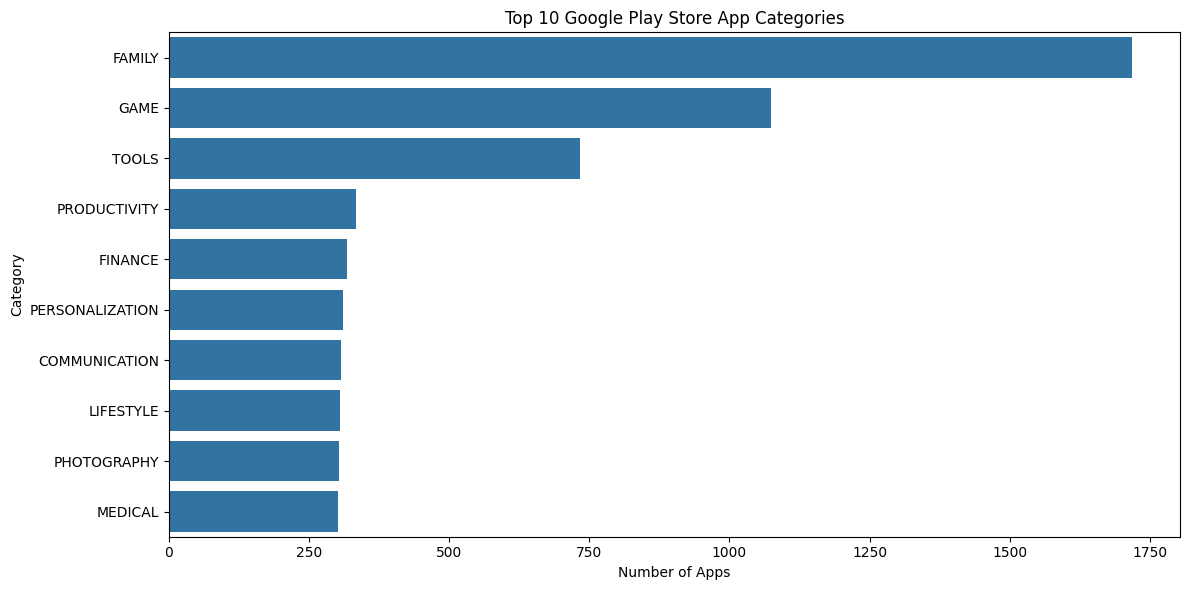

Category analysis completed!


In [5]:
# Count apps in each category
category_counts = df["Category"].value_counts()

print("Total app categories:", df["Category"].nunique())
print("\nTop 10 categories:")
display(category_counts.head(10))

# Visualize the top 10 categories
plt.figure(figsize=(12, 6))
sns.barplot(
    x=category_counts.head(10).values,
    y=category_counts.head(10).index
)
plt.title("Top 10 Google Play Store App Categories")
plt.xlabel("Number of Apps")
plt.ylabel("Category")
plt.tight_layout()
plt.show()

print("Category analysis completed!")




Average app rating: 4.19
Highest app rating: 5.0
Lowest app rating: 1.0


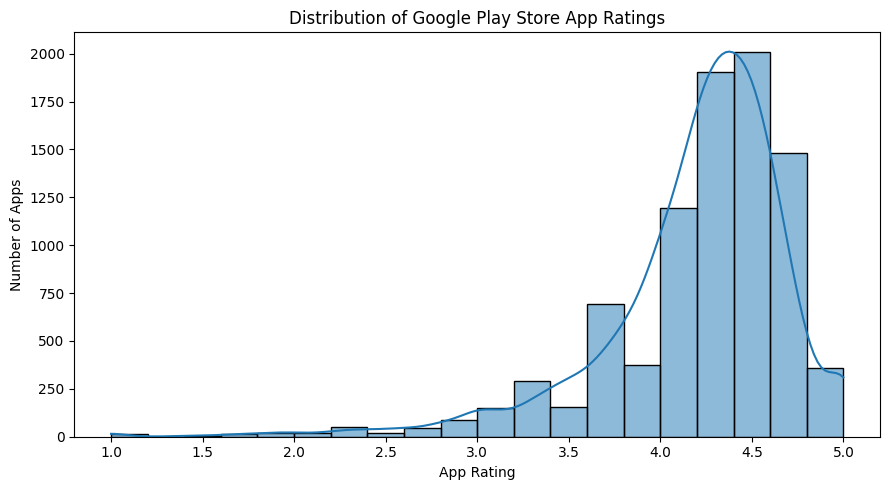


Top 10 categories by average rating:


,Rating
Category,
EVENTS,4.44
EDUCATION,4.38
ART_AND_DESIGN,4.36
BOOKS_AND_REFERENCE,4.35
PERSONALIZATION,4.33
PARENTING,4.30
GAME,4.28
BEAUTY,4.28
HEALTH_AND_FITNESS,4.26



Rating analysis completed!


In [6]:
# Calculate rating statistics
print("Average app rating:", round(df["Rating"].mean(), 2))
print("Highest app rating:", df["Rating"].max())
print("Lowest app rating:", df["Rating"].min())

# Plot rating distribution
plt.figure(figsize=(9, 5))
sns.histplot(df["Rating"], bins=20, kde=True)
plt.title("Distribution of Google Play Store App Ratings")
plt.xlabel("App Rating")
plt.ylabel("Number of Apps")
plt.tight_layout()
plt.show()

# Rating by app category
category_ratings = (
    df.groupby("Category")["Rating"]
    .mean()
    .sort_values(ascending=False)
)

print("\nTop 10 categories by average rating:")
display(category_ratings.head(10).round(2))

print("\nRating analysis completed!")




Top 10 Apps by Installs:


,App,Category,Installs,Rating
3896,Subway Surfers,GAME,1000000000,4.5
4153,Hangouts,COMMUNICATION,1000000000,4.0
4150,Google,TOOLS,1000000000,4.4
3904,WhatsApp Messenger,COMMUNICATION,1000000000,4.4
3816,Google News,NEWS_AND_MAGAZINES,1000000000,3.9
3127,Google Street View,TRAVEL_AND_LOCAL,1000000000,4.2
3909,Instagram,SOCIAL,1000000000,4.5
4144,Google+,SOCIAL,1000000000,4.2
3523,Google Drive,PRODUCTIVITY,1000000000,4.4
2853,Google Photos,PHOTOGRAPHY,1000000000,4.5


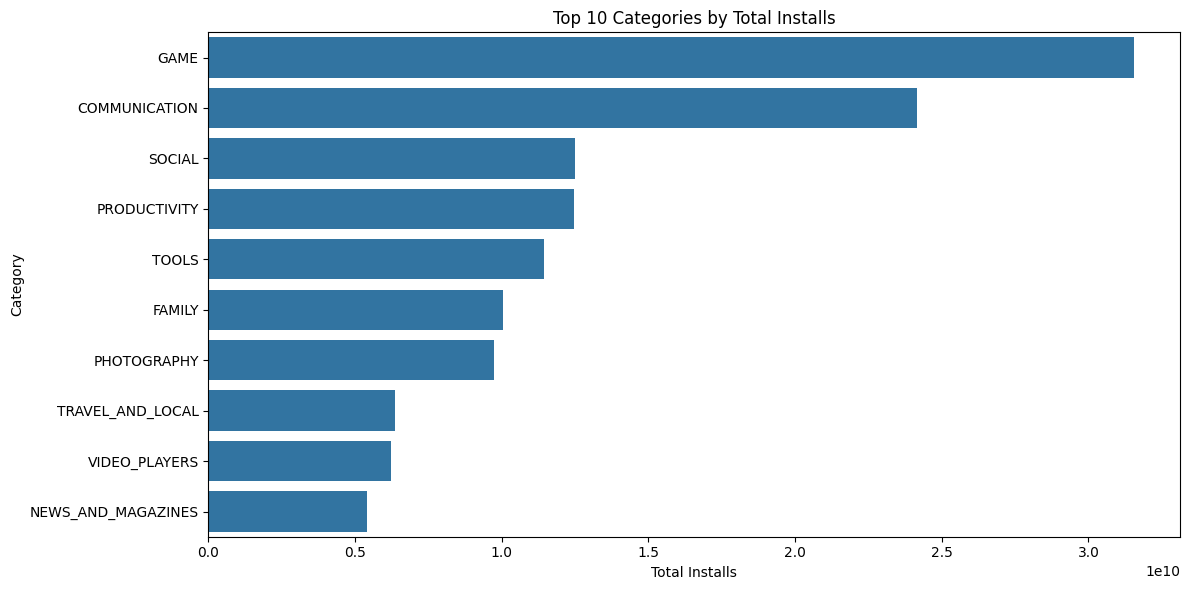

Install analysis completed!


In [7]:
# Clean the Installs column
df["Installs"] = (
    df["Installs"].astype(str)
    .str.replace(",", "", regex=False)
    .str.replace("+", "", regex=False)
)

df["Installs"] = pd.to_numeric(df["Installs"], errors="coerce")

# Remove rows with invalid install counts
df = df.dropna(subset=["Installs"])

# Top 10 apps by installs
top_apps = (
    df.sort_values("Installs", ascending=False)
    [["App", "Category", "Installs", "Rating"]]
    .drop_duplicates(subset=["App"])
    .head(10)
)

print("Top 10 Apps by Installs:")
display(top_apps)

# Plot most-installed categories
category_installs = (
    df.groupby("Category")["Installs"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

plt.figure(figsize=(12, 6))
sns.barplot(
    x=category_installs.values,
    y=category_installs.index
)
plt.title("Top 10 Categories by Total Installs")
plt.xlabel("Total Installs")
plt.ylabel("Category")
plt.tight_layout()
plt.show()

print("Install analysis completed!")




Free vs Paid Apps:


,count
App Type,
Free,8279
Paid,613


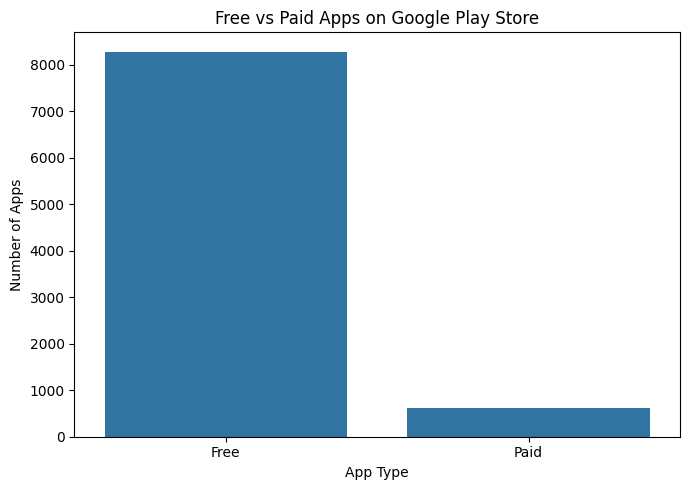


Average rating by app type:


,Rating
App Type,
Free,4.18
Paid,4.26


Free vs paid analysis completed!


In [8]:
# Clean the Price column
df["Price"] = (
    df["Price"].astype(str)
    .str.replace("$", "", regex=False)
)

df["Price"] = pd.to_numeric(df["Price"], errors="coerce")
df = df.dropna(subset=["Price"])

# Classify apps as Free or Paid
df["App Type"] = np.where(df["Price"] == 0, "Free", "Paid")

print("Free vs Paid Apps:")
display(df["App Type"].value_counts())

# Plot the comparison
plt.figure(figsize=(7, 5))
sns.countplot(data=df, x="App Type")
plt.title("Free vs Paid Apps on Google Play Store")
plt.xlabel("App Type")
plt.ylabel("Number of Apps")
plt.tight_layout()
plt.show()

# Compare average ratings
print("\nAverage rating by app type:")
display(df.groupby("App Type")["Rating"].mean().round(2))

print("Free vs paid analysis completed!")




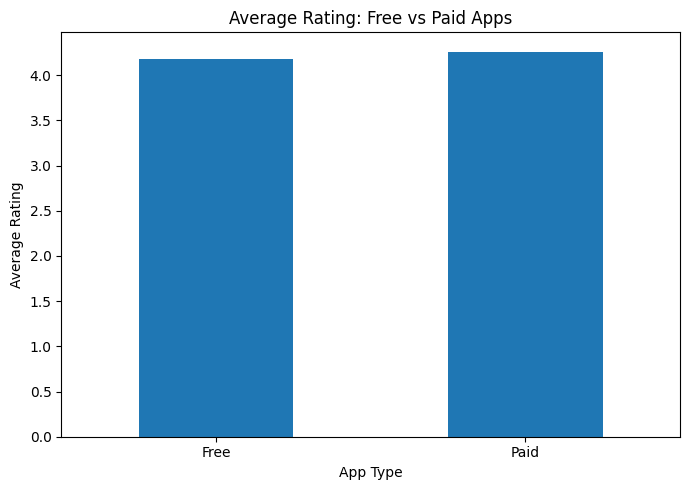

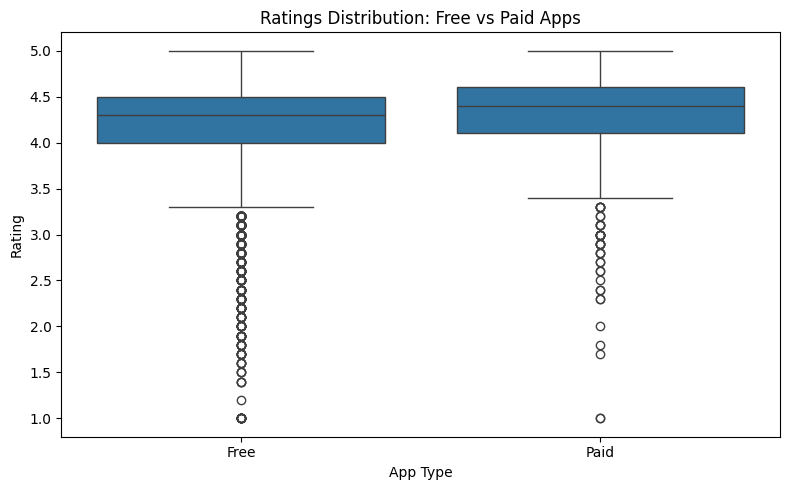

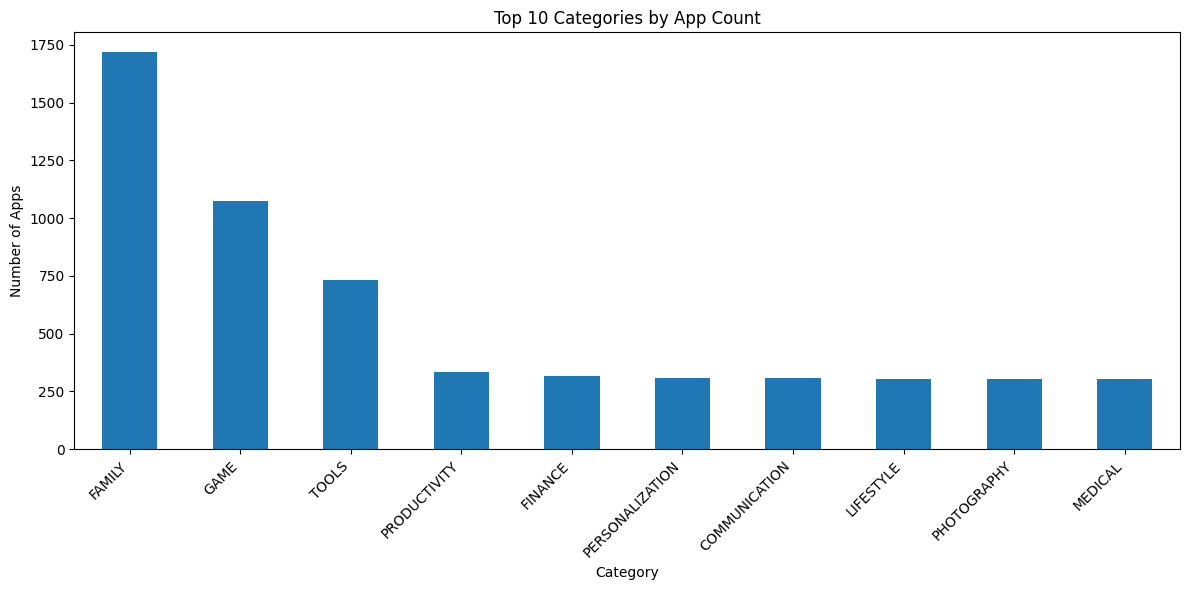

Final visualizations completed!


In [9]:
# Graph 1: Average rating by app type
rating_by_type = df.groupby("App Type")["Rating"].mean()

plt.figure(figsize=(7, 5))
rating_by_type.plot(kind="bar")
plt.title("Average Rating: Free vs Paid Apps")
plt.xlabel("App Type")
plt.ylabel("Average Rating")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

# Graph 2: Reviews vs Ratings
plt.figure(figsize=(8, 5))
sns.boxplot(data=df, x="App Type", y="Rating")
plt.title("Ratings Distribution: Free vs Paid Apps")
plt.xlabel("App Type")
plt.ylabel("Rating")
plt.tight_layout()
plt.show()

# Graph 3: Top 10 categories by app count
top_categories = df["Category"].value_counts().head(10)

plt.figure(figsize=(12, 6))
top_categories.plot(kind="bar")
plt.title("Top 10 Categories by App Count")
plt.xlabel("Category")
plt.ylabel("Number of Apps")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

print("Final visualizations completed!")




In [10]:
print("=" * 50)
print("GOOGLE PLAY STORE ANALYSIS - CONCLUSION")
print("=" * 50)

print("\n1. Dataset Overview")
print("Total apps analysed:", df["App"].nunique())
print("Total categories:", df["Category"].nunique())

print("\n2. Rating Analysis")
print("Average app rating:", round(df["Rating"].mean(), 2))

print("\n3. Free vs Paid Apps")
display(df["App Type"].value_counts())

print("\n4. Top App Categories")
display(df["Category"].value_counts().head(5))

print("\nConclusion:")
print("This project analysed Google Play Store applications.")
print("The analysis explored app categories, ratings, installs, and prices.")
print("Visualizations helped compare app popularity and rating patterns.")
print("This analysis can help developers understand trends in the app market.")
print("\nProject completed!")




GOOGLE PLAY STORE ANALYSIS - CONCLUSION

1. Dataset Overview
Total apps analysed: 8196
Total categories: 33

2. Rating Analysis
Average app rating: 4.19

3. Free vs Paid Apps


,count
App Type,
Free,8279
Paid,613



4. Top App Categories


,count
Category,
FAMILY,1718
GAME,1074
TOOLS,734
PRODUCTIVITY,334
FINANCE,317



Conclusion:
This project analysed Google Play Store applications.
The analysis explored app categories, ratings, installs, and prices.
Visualizations helped compare app popularity and rating patterns.
This analysis can help developers understand trends in the app market.

Project completed!
